<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 1.00e-04 | train loss 1.1339 acc 0.584 | val loss 0.6282 acc 0.741 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 1.00e-04 | train loss 0.6084 acc 0.751 | val loss 0.5101 acc 0.798 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 1.00e-04 | train loss 0.4220 acc 0.824 | val loss 0.4140 acc 0.841 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 1.00e-04 | train loss 0.3700 acc 0.849 | val loss 0.3375 acc 0.873 *


...

[ConvNeXt-Tiny] Epoch  14/100 | LR: 1.00e-04 | train loss 0.1005 acc 0.960 | val loss 0.3400 acc 0.895


[ConvNeXt-Tiny] Epoch  15/100 | LR: 1.00e-05 | train loss 0.0739 acc 0.970 | val loss 0.5098 acc 0.861


[ConvNeXt-Tiny] Epoch  16/100 | LR: 1.00e-05 | train loss 0.0339 acc 0.986 | val loss 0.3819 acc 0.893


[ConvNeXt-Tiny] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0335 acc 0.986 | val loss 0.3701 acc 0.898


[ConvNeXt-Tiny] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0266 acc 0.988 | val loss 0.3779 acc 0.895

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 18.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3186)


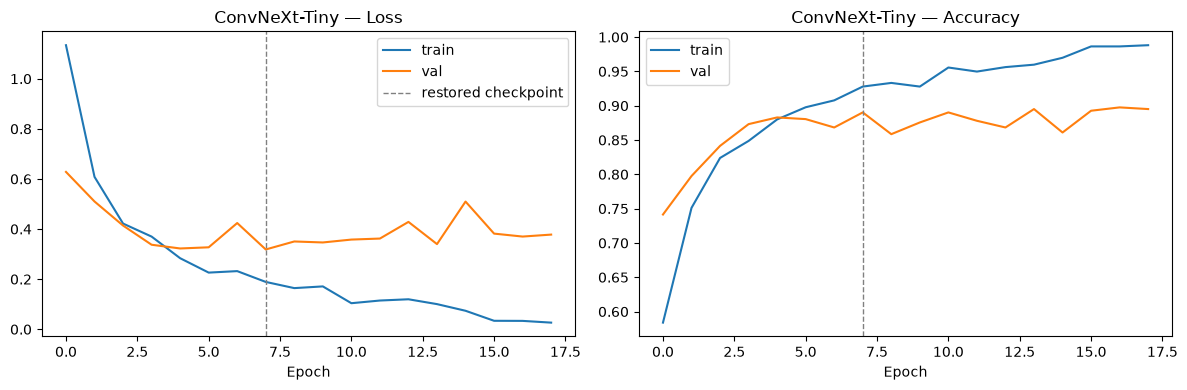

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.832


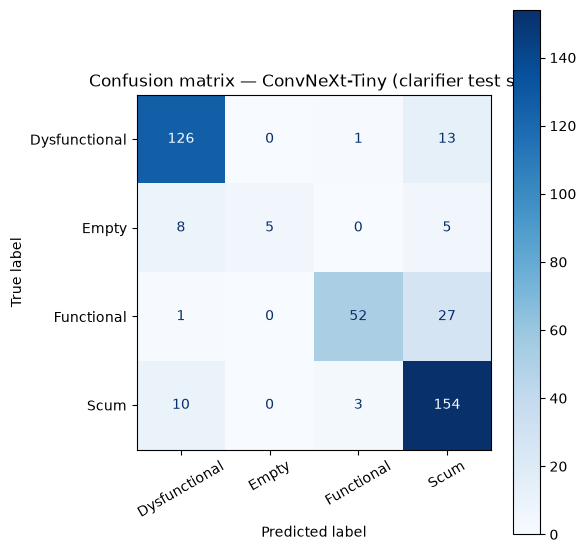

               precision    recall  f1-score   support

Dysfunctional      0.869     0.900     0.884       140
        Empty      1.000     0.278     0.435        18
   Functional      0.929     0.650     0.765        80
         Scum      0.774     0.922     0.842       167

     accuracy                          0.832       405
    macro avg      0.893     0.687     0.731       405
 weighted avg      0.847     0.832     0.823       405



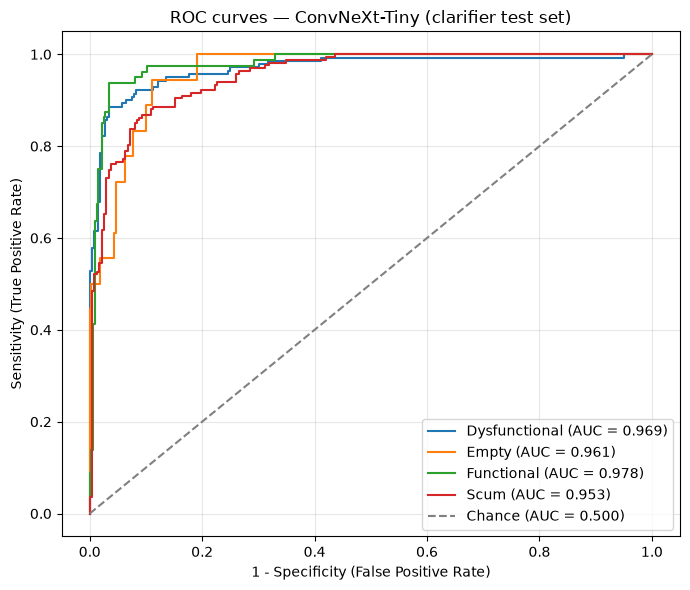

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.969
  Empty          : 0.961
  Functional     : 0.978
  Scum           : 0.953

Mean AUC (over 4/4 classes with test examples): 0.965


(np.float64(0.8320987654320988),
 {'Dysfunctional': 0.9688409703504044,
  'Empty': 0.9610967556703991,
  'Functional': 0.9783461538461539,
  'Scum': 0.9530518794344085})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
